<a href="https://colab.research.google.com/github/hemanthg3/Multi-Class-Classification-using-Iris-Dataset/blob/main/Multi_Class_Classification_using_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, precision_score,
                             recall_score, f1_score, roc_curve, auc)
from sklearn.multiclass import OneVsRestClassifier

import pickle

sns.set(style="whitegrid")

# **Load Dataset**

In [2]:
data = load_iris()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Dataset Shape:", X.shape)
X.head()

Dataset Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


# **Train-Test Split**

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Create sklearn Pipeline**

In [6]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=200))
])

# **Train Model**

In [7]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=200))])

# **Predictions**

In [9]:
y_pred = pipeline.predict(X_test)

# **Accuracy Report**

In [10]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


# **Confusion Matrix**

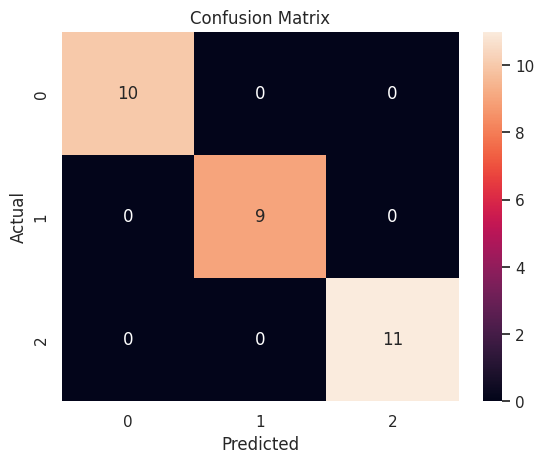

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Classification Report**

In [13]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# **Metric Table**

In [14]:
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df

,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0


# **ROC-AUC Curve (Multi-Class)**

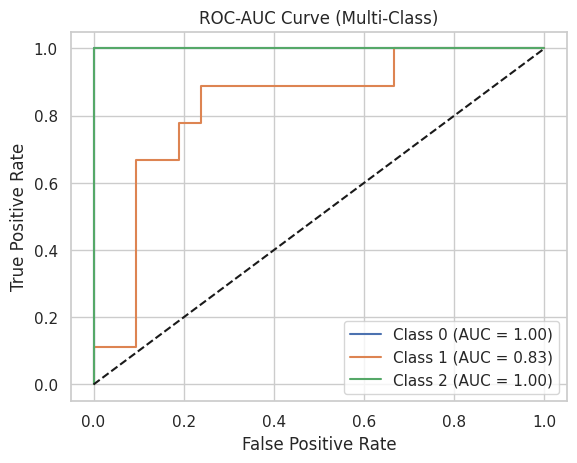

In [15]:
# Binarize output
y_bin = label_binarize(y, classes=[0,1,2])

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

# One-vs-Rest Model
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=200))
ovr_model.fit(X_train_bin, y_train_bin)

y_score = ovr_model.predict_proba(X_test_bin)

# Plot ROC Curve
plt.figure()

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC-AUC Curve (Multi-Class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# **Save Model (.pkl)**

In [16]:
with open("iris_model.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved as iris_model.pkl")

Model saved as iris_model.pkl


# **Load Model**

In [17]:
with open("iris_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)

print("Loaded model prediction:", loaded_model.predict(X_test[:5]))

Loaded model prediction: [1 0 2 1 1]
